# Plant-Soil-Microbe interactions with EcoSIM

EcoSIM is an advanced simulation framework for the realistic portrayal of plant-soil-microbe interactions across scales that can be used for a wide range of land modeling applications. EcoSIM has functional modules for

* Ecohydrology (Vegetation traits, Multilayer radiation, Photosynthesis, Canopy energy balance, Dynamic allocation, Dynamic shoot growth, and Dynamic root growth)
* Microbiology (Microbial traits such as Size, shape, surface area (constraints uptake), Cell stoichiometry, $\mu_{\text{max}}, T_{\text{opt}}$, and Symbionts such as Mycorrhizae, Diazotrophs)
* Biogeochemistry (Bacterial heterotrophs - fungal saprotrophs, Nitrate reduction, N fixation, Ammonia - nitrite oxidation, Fermentation, Methanogenesis, Methane oxidation)
* Geology/Geochemistry (Organo-mineral interactions, Aqueous chemistry, Salinity, Erosion)
* Disturbance and management (Wildfire - insects, Ecosystem management, Agriculture, Forestry)

As a result, it can perform calculations of many of the fluxes relevant in the ecosystem-based, integrated, distributed hydrology simulations ATS performs. We are taking a phased approach to couple EcoSIM to the multiphysics-framework that is the backbone of ATS. An EcoSIM process kernel (PK) will use process models in EcoSIM to compute the associated flux contributions to be applied in the appropriate ATS conservation equations. 

In the current phase, the coupling allows for the calculation of evapotranspiration (ET), a key parameters in the energy and water balance, capturing also the snow dyamics, via a prescribed phenology approach (i.e. vegetation evolution is not considered). 

The set of simulations presented here demonstrates the current set of capabilities by varying controlling parameters such as albedo or phenology, and checking the response in the form of: 

* **snow dynamics**
  * snow accumulation
  * snow melting
  * snow sublimation
  * snow evaporation
* **evapotranspiration**
  * root transpiration

Authors: Sergi Molins (demo doc, demos), Andrew Graus (ATS-EcoSIM dev, demos), Jinyun Tang (EcoSIM dev)

In [1]:
%matplotlib inline

In [2]:
import sys,os
sys.path.append(os.path.join(os.environ['ATS_SRC_DIR'],'tools', 'utils'))
sys.path.append(os.path.join(os.environ['ATS_SRC_DIR'],'docs', 'documentation', 'source', 'ats_demos'))

import ats_xdmf
#import colors
import numpy as np
from matplotlib import pyplot as plt
#from matplotlib import colorbar
import pandas
#import run_demos

#import h5py

## Surface-Subsurface column domain: Base case

These simulations consist of a 25 m-tall column that is subject to a meteorological forcing dataset sourced from the Taylor River watershed, CO, a subbasin part of the LBNL/SLAC Watershed Function SFA study area. In this mountainous area, precipitation accumulates in the form of snow in the winter, which then melts during the early spring. The forcing dataset (and simulation) includes a period of five years of varying precipitation.

The domain includes a surface and subsurface subdomains, and the EcoSIM pK applies to both subdomains.

In the base case, no albedo value is provided in the ATS input file, thus letting EcoSIM use its internal albedo value: 
```xml
<Parameter name="Prescribe Albedo" type="bool" value="false" />
```
Further, no vegetation is included:
```xml
<Parameter name="Prescribe Phenology" type="bool" value="false" />
```
The resulting evolution of the snow in the ground (snow depth) reflects the response to this forcing dataset. In what follows, we plot the evolution of the snow depth with time over the 5-year simulation.

## Snow accumulation: base case

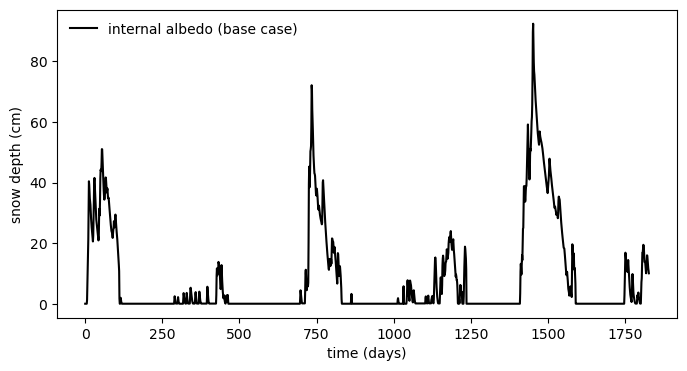

In [3]:
dir_base = "snow_dynamics_albedo_internal.demo"
base = pandas.read_csv(os.path.join(dir_base, 'snow_status.dat'), comment='#')
fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.plot(base['time [s]'][:]/86400, base['snow_depth'][:]*100., color='k', label="internal albedo (base case)")

ax.set_xlabel("time (days)")
ax.set_ylabel("snow depth (cm)")
ax.legend(frameon=False)
plt.show()

## Albedo options: snow dynamics

In addition to letting EcoSIM control the albedo value, one can control the albedo that will be used by EcoSIM from the ATS input file. Two values of albedo are used as an eample of how to do that: 

- A relatively low albedo value is provided in the ATS input file and passed to EcoSIM (albedo = 0.3)
- A relatively high albedo value is provided in the ATS input file and passed to EcoSIM (albedo = 0.9)
 
These low and high albedo values result in these changes in the evolution of the snow depth with time over the 5-year simulation.

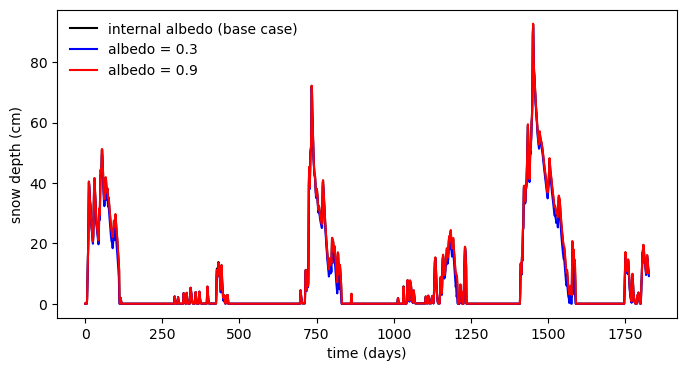

In [4]:
dir_lo_albedo = "snow_dynamics_albedo_low.demo"
dir_hi_albedo = "snow_dynamics_albedo_high.demo"

lo_albedo = pandas.read_csv(os.path.join(dir_lo_albedo, 'snow_status.dat'), comment='#')
hi_albedo = pandas.read_csv(os.path.join(dir_hi_albedo, 'snow_status.dat'), comment='#')

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.plot(base['time [s]'][:]/86400, base['snow_depth'][:]*100., color='k', label="internal albedo (base case)")
ax.plot(lo_albedo['time [s]'][:]/86400, lo_albedo['snow_depth'][:]*100., color='b', label="albedo = 0.3")
ax.plot(hi_albedo['time [s]'][:]/86400, hi_albedo['snow_depth'][:]*100., color='r', label="albedo = 0.9")

ax.set_xlabel("time (days)")
ax.set_ylabel("snow depth (cm)")
ax.legend(frameon=False)
plt.show()

The differences are small and better seen in specific periods of time, showing more snow accumulation at high albedo and less at low albedo, with the base case (EcoSIM internal albedo) falling somewhere in between. We zoom into these periods:

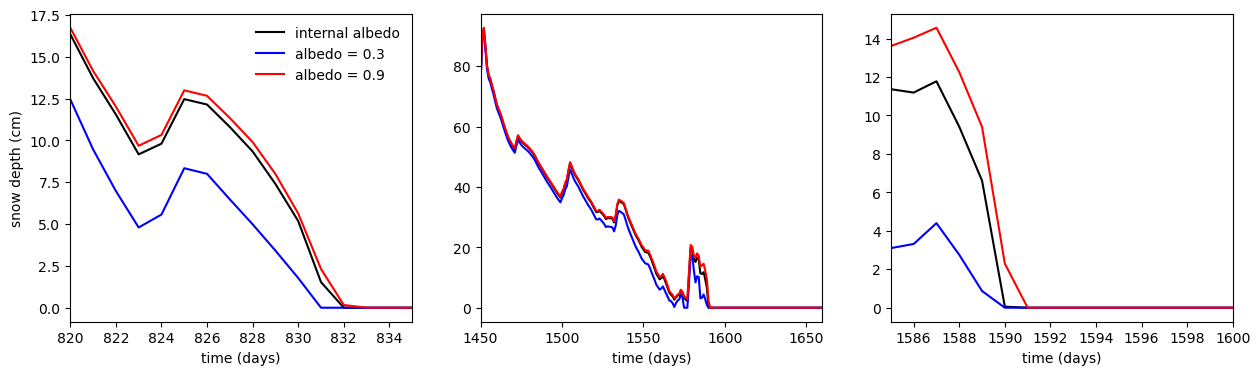

In [5]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

# periods of interest
periods = [(820, 835), (1450, 1660), (1585, 1600)]

for i, (t1, t2) in enumerate(periods):
    # Slice data for this period to ensure y-axis autoscales correctly
    mask_no = (base['time [s]']/86400 >= t1) & (base['time [s]']/86400 <= t2)
    mask_lo = (lo_albedo['time [s]']/86400 >= t1) & (lo_albedo['time [s]']/86400 <= t2)
    mask_hi = (hi_albedo['time [s]']/86400 >= t1) & (hi_albedo['time [s]']/86400 <= t2)

    ax[i].plot(base['time [s]'][mask_no]/86400, base['snow_depth'][mask_no]*100., color='k', label="internal albedo")
    ax[i].plot(lo_albedo['time [s]'][mask_lo]/86400, lo_albedo['snow_depth'][mask_lo]*100., color='b', label="albedo = 0.3")
    ax[i].plot(hi_albedo['time [s]'][mask_hi]/86400, hi_albedo['snow_depth'][mask_hi]*100., color='r', label="albedo = 0.9")

    ax[i].set_xlabel("time (days)")
    ax[i].set_xlim(t1, t2)

ax[0].set_ylabel("snow depth (cm)")
ax[0].legend(frameon=False)
plt.show()

## Phenology options: snow dynamics

Generally, EcoSIM can handle vegetation dynamics and evolution. However, a new capability has been developed along with the coupler to ATS such that the user can provide a vegetation distribution that will not evolve. This will allow for direct comparison of model results (and for setting a baseline) with results of ATS (and other codes) that calculate evapotranspiration (ET) without considering the evolution of the vegetation (see the 05_ecohydrology notebooks). This option is referred to as **Prescribed Phenology**.

Adding vegetation cover to the column significantly changes the amount of snow that accumulates on the surface domain over the simulated period in comparison to the baseline calculations.

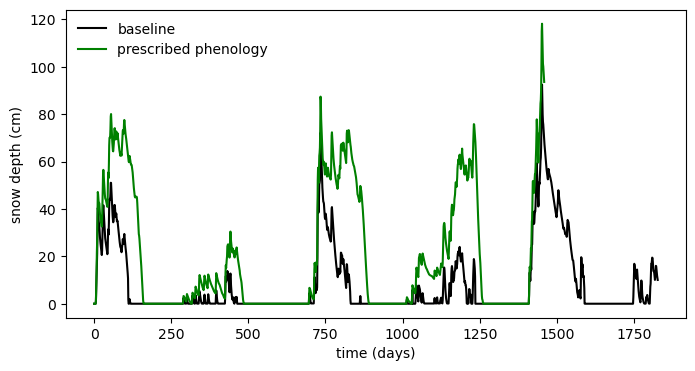

In [6]:
dir_pheno_root = "snow_dynamics_phenology_roots.demo"

ss_base = pandas.read_csv(os.path.join(dir_base, 'snow_status.dat'), comment='#')
ss_phen = pandas.read_csv(os.path.join(dir_pheno_root, 'surf_prop.dat'), comment='#')

time = ss_base['time [s]']/86400
t_phen = ss_phen['time [s]']/86400
sd_base = ss_base['snow_depth']
sd_phen = ss_phen['snow_depth']

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(time,sd_base*100.,color='k', label="baseline")
ax.plot(t_phen,sd_phen*100.,color='g', label="prescribed phenology")
ax.legend(frameon=False)
ax.set_xlabel("time (days)")
ax.set_ylabel("snow depth (cm)")
plt.show()

## Phenology options: water fluxes and saturation

Vegetation also pulls water from the subsurface via root processes as captured by EcoSIM. This flux is available in each grid cell of the subsurface domain via the `subsurface_ecosim_water_source` evaluator. Here we integrate this flux in two ways, one is into the `Q_w_subsurf` observation and the other is reading it and doing the integration via `np.sum`

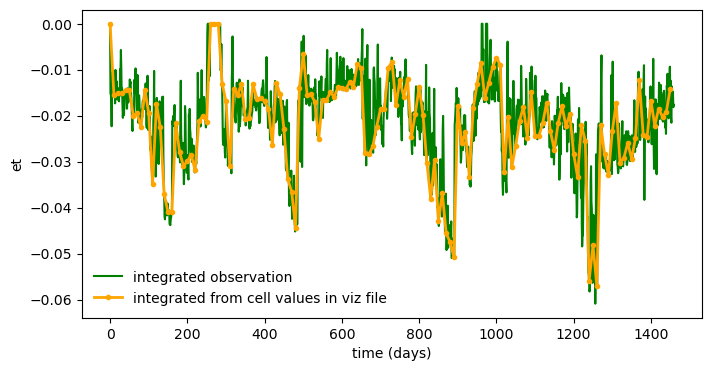

In [14]:
## observation of the integrated subsurface flux
sb_phen = pandas.read_csv(os.path.join(dir_pheno_root, 'subsurf_prop.dat'), comment='#')
t_phen = sb_phen['time [s]']/86400
et_phen = sb_phen['Q_w_subsurf']

## from the visualization file
vis = ats_xdmf.VisFile(dir_pheno_root)
root_flux = vis.getArray('subsurface_ecosim_water_source')
total_flux = np.sum(root_flux,axis=1)
time = vis.times

fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(t_phen,et_phen*100.,color='g', label="integrated observation")
ax.plot(time*365.25,total_flux*100,marker='.',color='orange',lw=2,label="integrated from cell values in viz file")
ax.legend(frameon=False)
ax.set_xlabel("time (days)")
ax.set_ylabel("et")
plt.show()

As a result of the root processes, the water saturation in the column falls below that in the base case. Here we show the saturation in the top grid cell of the subsurface, comparing both cases.

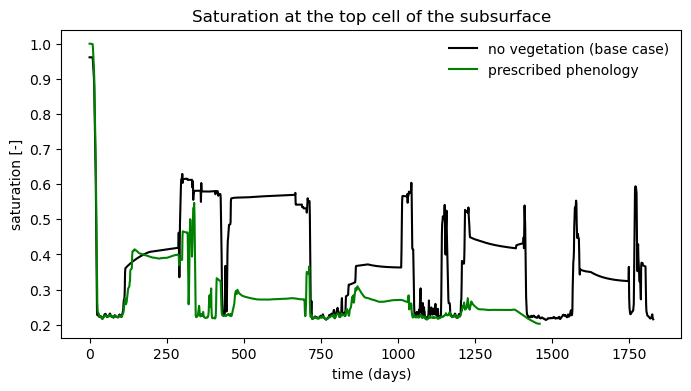

In [15]:
t_base = ss_base['time [s]']/86400
wc_base = ss_base['saturation_liquid']

t_phen = sb_phen['time [s]']/86400
wc_phen = sb_phen['saturation_liquid']

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.plot(t_base,wc_base,color='k', label="no vegetation (base case)")
ax.plot(t_phen,wc_phen,color='g', label="prescribed phenology")

plt.legend(loc='upper right',frameon=False)
ax.set_title("Saturation at the top cell of the subsurface")
ax.set_xlabel("time (days)")
ax.set_ylabel("saturation [-]")
plt.show()

## Phenology options: Evapotranspirative fluxes

We can also compare the evaportranspirative fluxes calculated by the code for the base case and for the case with prescribed phenology. four fluxes are available from EcoSIM. 

- Evapotranspiration (ET) is the total evapotranspirative flux.
- Ground evaporation is the evaporation from the ground.
- Snow evaporation is the evaporation from the snow.
- Snow sublimation is the evaporation from the snow.

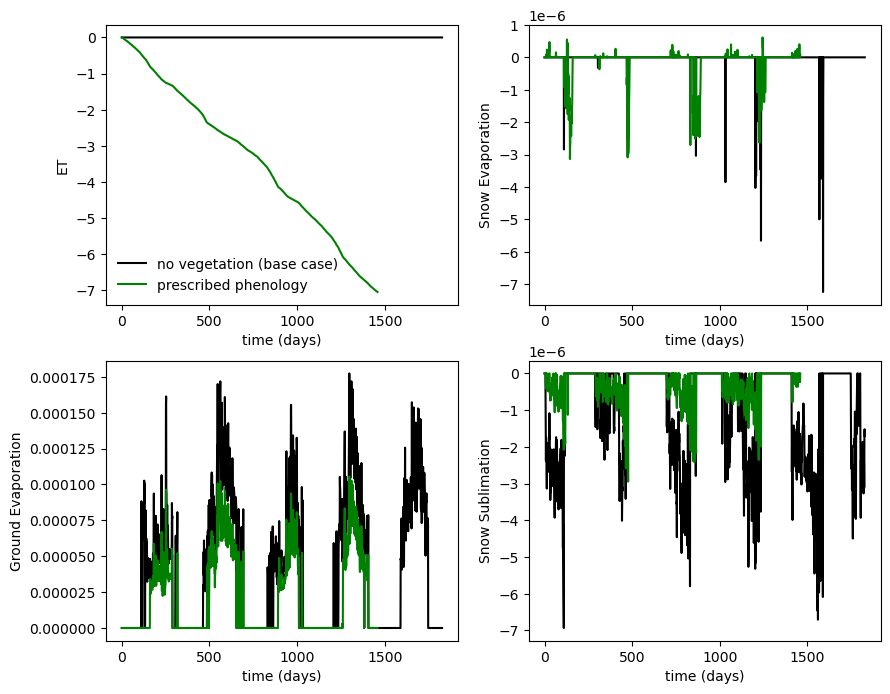

In [33]:
## observation of the integrated subsurface flux
ev_base = pandas.read_csv(os.path.join(dir_base, 'evapotranspiration.dat'), comment='#')

t_base = ev_base['time [s]']/86400
et_base = ev_base['evapotranspiration']
eg_base = ev_base['evaporation_ground']
es_base = ev_base['evaporation_snow']
su_base = ev_base['sublimation_snow']

t_phen = ss_phen['time [s]']/86400
et_phen = ss_phen['evapotranspiration']
eg_phen = ss_phen['evaporation_ground']
es_phen = ss_phen['evaporation_snow']
su_phen = ss_phen['sublimation_snow']

fig, ax = plt.subplots(2,2, figsize=(10,8))

ax[0,0].plot(t_base,et_base,color='k', label="no vegetation (base case)")
ax[0,0].plot(t_phen,et_phen,color='g', label="prescribed phenology")

ax[1,0].plot(t_base,eg_base,color='k', label="no vegetation (base case)")
ax[1,0].plot(t_phen,eg_phen,color='g', label="prescribed phenology")

ax[0,1].plot(t_base,es_base,color='k', label="no vegetation (base case)")
ax[0,1].plot(t_phen,es_phen,color='g', label="prescribed phenology")

ax[1,1].plot(t_base,su_base,color='k', label="no vegetation (base case)")
ax[1,1].plot(t_phen,su_phen,color='g', label="prescribed phenology")


ax[0,0].legend(frameon=False)
for each in ax.flatten():
    each.set_xlabel("time (days)")

ax[0,0].set_ylabel("ET")
ax[1,0].set_ylabel("Ground Evaporation")
ax[0,1].set_ylabel("Snow Evaporation")
ax[1,1].set_ylabel("Snow Sublimation")
plt.show()